In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from scipy import stats

In [2]:
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, ROOT)

from src.split_data import split_data

cancerous = {"BCC", "SCC", "MEL"}

def make_features_labels(df, extra_drops=()):
    drops = ["img_id", "diagnostic", "Unnamed: 0", *extra_drops]
    features = df.drop(columns=drops, errors="ignore").select_dtypes(include="number")
    labels = np.where(df["diagnostic"].isin(cancerous), "cancerous", "non-cancerous")
    return features, labels

def make_forest(seed=6, n_estimators=200, max_depth=None):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        class_weight="balanced",
        random_state=seed,
    )

In [3]:
features_path = os.path.join(ROOT, "data", "features.csv")
splits_dir    = os.path.join(ROOT, "data", "splits")
train_df, val_df, test_df = split_data(features_path, 0.65, 0.20, 42, splits_dir)

_, train_labels = make_features_labels(train_df)
_, val_labels   = make_features_labels(val_df)
_, test_labels  = make_features_labels(test_df)

contrast_cols = ["contrast_diff", "contrast_ratio", "contrast_standardized"]
scenarios = [
    ["none",                  contrast_cols],
    ["contrast_diff",         ["contrast_ratio", "contrast_standardized"]],
    ["contrast_ratio",        ["contrast_diff", "contrast_standardized"]],
    ["contrast_standardized", ["contrast_diff", "contrast_ratio"]],
    ["all",                   []],
]

In [4]:
results = {}
for name, drops in scenarios:
    train_X, _ = make_features_labels(train_df, drops)
    val_X,   _ = make_features_labels(val_df,   drops)
    test_X,  _ = make_features_labels(test_df,  drops)

    forest = make_forest()
    forest.fit(train_X, train_labels)

    val_preds  = forest.predict(val_X)
    test_preds = forest.predict(test_X)
    val_acc    = forest.score(val_X, val_labels)
    test_acc   = forest.score(test_X, test_labels)

    results[name] = dict(val_preds=val_preds, test_preds=test_preds,
                         val_acc=val_acc,     test_acc=test_acc)
    print(f"{name:25s}  val={val_acc:.3f}  test={test_acc:.3f}")

none                       val=0.745  test=0.741
contrast_diff              val=0.740  test=0.732
contrast_ratio             val=0.750  test=0.738
contrast_standardized      val=0.757  test=0.729
all                        val=0.750  test=0.744


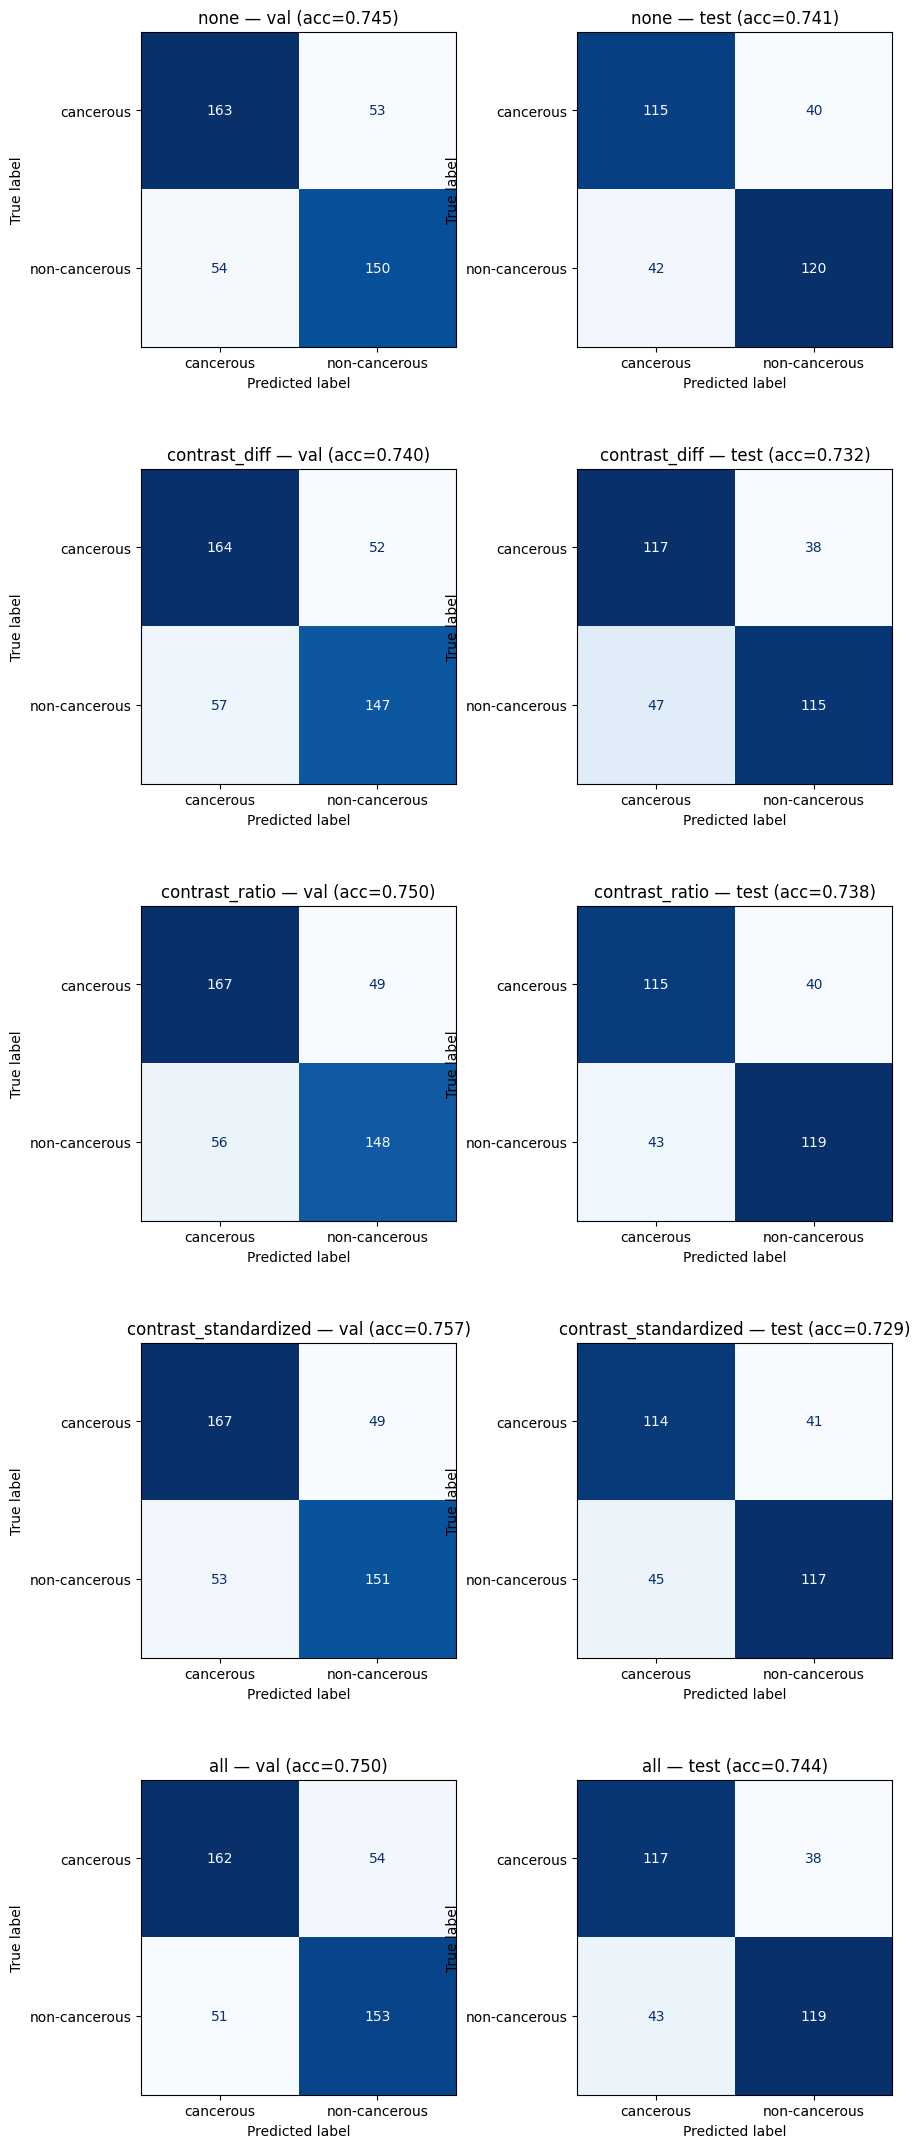

In [5]:
fig, axes = plt.subplots(5, 2, figsize=(9, 22))
for i, (name, r) in enumerate(results.items()):
    ConfusionMatrixDisplay.from_predictions(val_labels,  r["val_preds"],  cmap="Blues", ax=axes[i, 0], colorbar=False)
    ConfusionMatrixDisplay.from_predictions(test_labels, r["test_preds"], cmap="Blues", ax=axes[i, 1], colorbar=False)
    axes[i, 0].set_title(f"{name} — val (acc={r['val_acc']:.3f})")
    axes[i, 1].set_title(f"{name} — test (acc={r['test_acc']:.3f})")
plt.tight_layout()
plt.show()

In [6]:
N_SEEDS = 500
importances = {name: [] for name, _ in scenarios}
val_accs    = {name: [] for name, _ in scenarios}
test_accs   = {name: [] for name, _ in scenarios}

for seed in range(N_SEEDS):
    for name, drops in scenarios:
        train_X, _ = make_features_labels(train_df, drops)
        val_X,   _ = make_features_labels(val_df,   drops)
        test_X,  _ = make_features_labels(test_df,  drops)

        forest = make_forest(seed)
        forest.fit(train_X, train_labels)

        importances[name].append(pd.Series(forest.feature_importances_, index=train_X.columns))
        val_accs[name].append(forest.score(val_X, val_labels))
        test_accs[name].append(forest.score(test_X, test_labels))
    print(f"seed {seed+1}/{N_SEEDS} done")

importance_dfs = {name: pd.DataFrame(rows) for name, rows in importances.items()}
val_acc_df  = pd.DataFrame(val_accs)
test_acc_df = pd.DataFrame(test_accs)

seed 1/500 done
seed 2/500 done
seed 3/500 done
seed 4/500 done
seed 5/500 done
seed 6/500 done
seed 7/500 done
seed 8/500 done
seed 9/500 done
seed 10/500 done
seed 11/500 done
seed 12/500 done
seed 13/500 done
seed 14/500 done
seed 15/500 done
seed 16/500 done
seed 17/500 done
seed 18/500 done
seed 19/500 done
seed 20/500 done
seed 21/500 done
seed 22/500 done
seed 23/500 done
seed 24/500 done
seed 25/500 done
seed 26/500 done
seed 27/500 done
seed 28/500 done
seed 29/500 done
seed 30/500 done
seed 31/500 done
seed 32/500 done
seed 33/500 done
seed 34/500 done
seed 35/500 done
seed 36/500 done
seed 37/500 done
seed 38/500 done
seed 39/500 done
seed 40/500 done
seed 41/500 done
seed 42/500 done
seed 43/500 done
seed 44/500 done
seed 45/500 done
seed 46/500 done
seed 47/500 done
seed 48/500 done
seed 49/500 done
seed 50/500 done
seed 51/500 done
seed 52/500 done
seed 53/500 done
seed 54/500 done
seed 55/500 done
seed 56/500 done
seed 57/500 done
seed 58/500 done
seed 59/500 done
seed 6

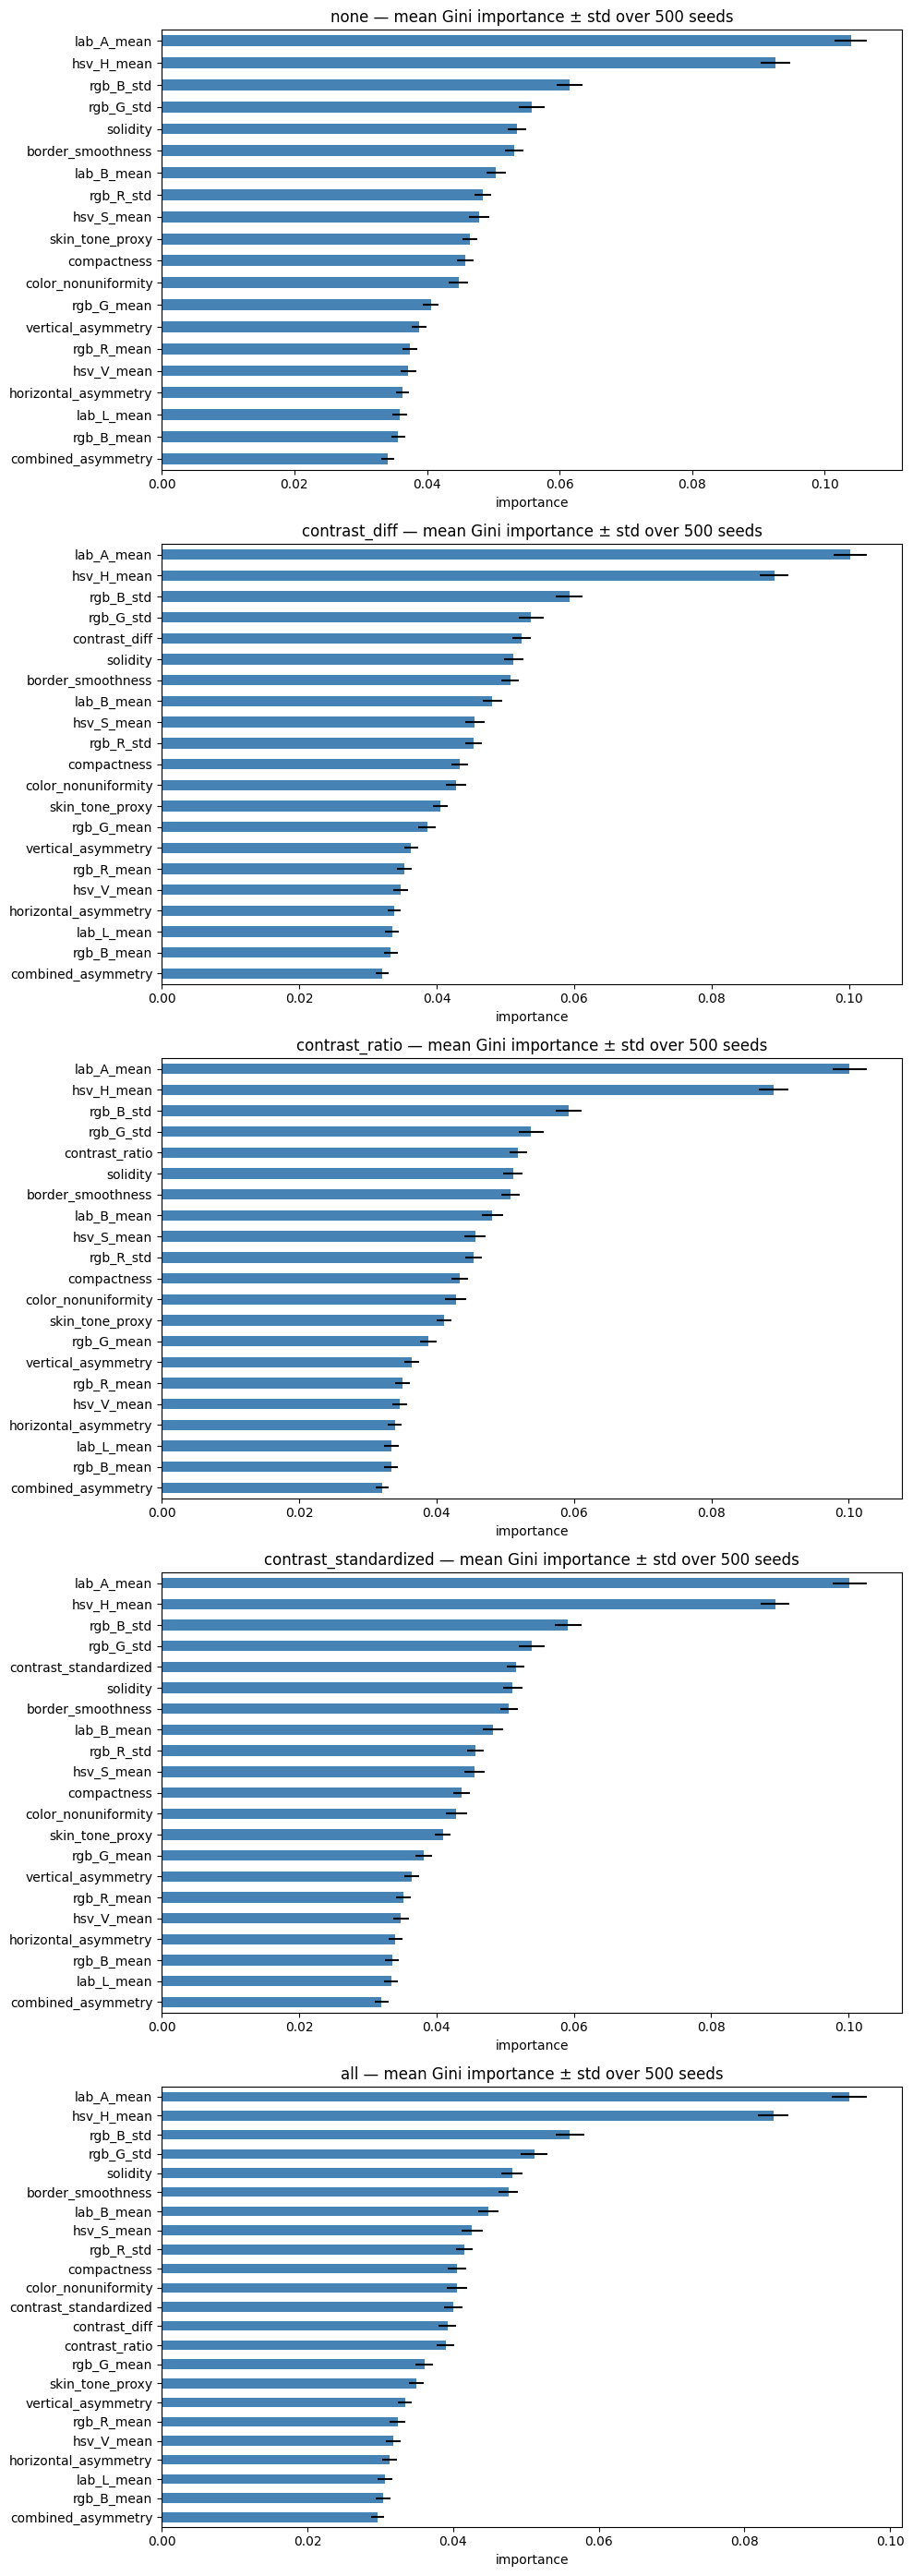

In [7]:
fig, axes = plt.subplots(5, 1, figsize=(10, 28))
for ax, (name, imp_df) in zip(axes, importance_dfs.items()):
    means = imp_df.mean().sort_values()
    stds  = imp_df.std().reindex(means.index)
    means.plot.barh(ax=ax, xerr=stds, color="steelblue", ecolor="black")
    ax.set_title(f"{name} — mean Gini importance ± std over {N_SEEDS} seeds")
    ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

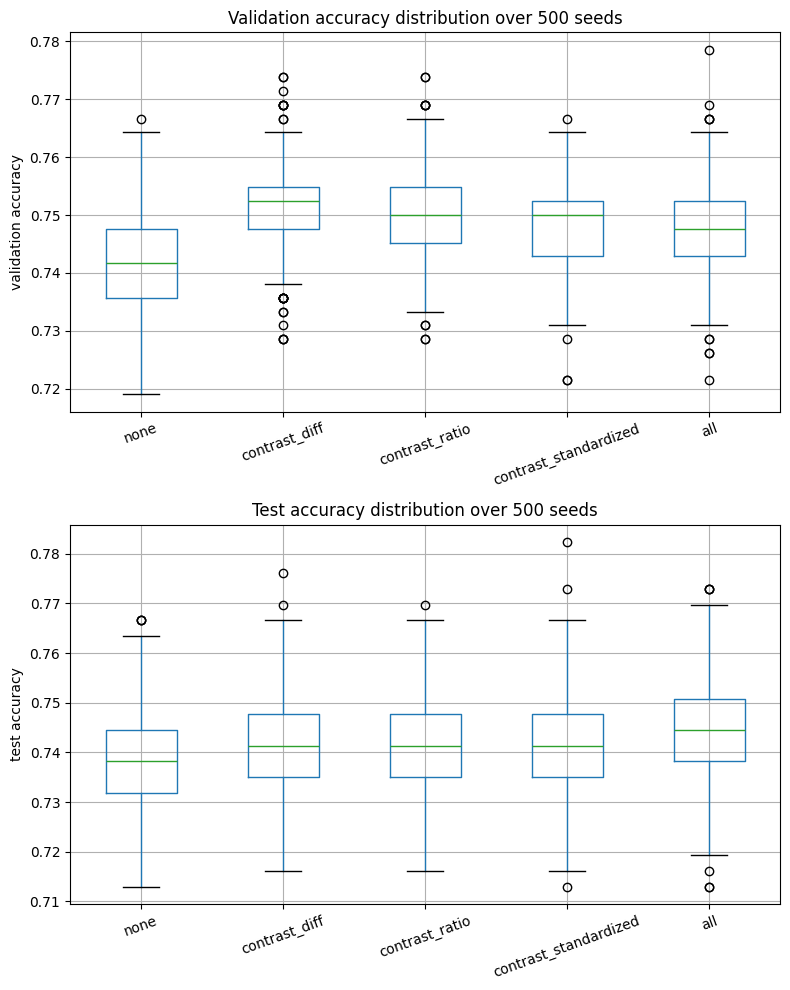

Paired Wilcoxon signed-rank test on test accuracy (vs. 'all'), n=500:
  scenario                     mean acc   mean diff                             p-value
  none                           0.7389     +0.0056  0.00000000000000002593258365666103
  contrast_diff                  0.7424     +0.0021  0.00072629548022983968398602616645
  contrast_ratio                 0.7413     +0.0032  0.00000022424614822982575656485618
  contrast_standardized          0.7416     +0.0029  0.00000439613294744559895499500662
  all                            0.7445  (baseline)                                    


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
val_acc_df.boxplot(ax=axes[0])
axes[0].set_ylabel("validation accuracy")
axes[0].set_title(f"Validation accuracy distribution over {N_SEEDS} seeds")
axes[0].tick_params(axis="x", rotation=20)

test_acc_df.boxplot(ax=axes[1])
axes[1].set_ylabel("test accuracy")
axes[1].set_title(f"Test accuracy distribution over {N_SEEDS} seeds")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# paired Wilcoxon vs. the 'all' baseline
print(f"Paired Wilcoxon signed-rank test on test accuracy (vs. 'all'), n={N_SEEDS}:")
print(f"  {'scenario':25s}  {'mean acc':>10s}  {'mean diff':>10s}  {'p-value':>34s}")
for name, _ in scenarios:
    mean_acc = test_acc_df[name].mean()
    if name == "all":
        print(f"  {name:25s}  {mean_acc:>10.4f}  {'(baseline)':>10s}  {'':>34s}")
        continue
    diffs = test_acc_df["all"] - test_acc_df[name]
    stat, p = stats.wilcoxon(test_acc_df["all"], test_acc_df[name], zero_method="wilcox")
    print(f"  {name:25s}  {mean_acc:>10.4f}  {diffs.mean():>+10.4f}  {p:>34.32f}")